### 과일 Data 를 CNN 으로 Image 분류

In [86]:
import numpy as np

fruits = np.load('../Data/fruits.npy')
fruits.shape

(300, 100, 100)

In [87]:
# Target 만들기
target = np.concatenate(
    [
        np.zeros(100),  # Apple
        np.ones(100),   # pineapple
        np.full(100, 2) # banana
    ]
)
target.shape

(300,)

----
#### train 과 test

In [88]:
from sklearn.model_selection import train_test_split

train = fruits.reshape(-1, 100, 100, 1) / 255.0     # 선형 회귀 출발이기 때문에 무조건 정규화 해야함. +) 정규화 해야 좋은지도 비교하면 좋음 (? 아마)

train_data, test_data, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

In [89]:
# 크기 확인
print(train_data.shape, test_data.shape)
print(train_target.shape, test_target.shape)

(240, 100, 100, 1) (60, 100, 100, 1)
(240,) (60,)


### CNN 만들기

In [90]:
from tensorflow import keras

In [91]:
# 1번째 CNN 층
model = keras.Sequential()
model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,  # 보통 정사각형으로 구성 (3,3)
        activation='relu',
        padding='same',  # 원본 이미지 크기과 같게  <=> valid
        input_shape=(100, 100, 1)
    )           # Conv2D(필터 갯수, 필터의 구성, 활성화 함수, padding, 형태)
)

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
model.add(
    keras.layers.MaxPooling2D(2)    # 2*2 max pooling
)

In [93]:
# 2번째 CNN 층
model.add(
    keras.layers.Conv2D(
        64,     # => 바뀜
        kernel_size=3,  # 보통 정사각형으로 구성 (3,3)
        activation='relu',
        padding='same',  # 원본 이미지 크기과 같게  <=> valid
    )
)
model.add(
    keras.layers.MaxPooling2D(2)    # 2*2 max pooling
)

In [94]:
# 입력층
model.add(
    keras.layers.Flatten()  # 평평하게 1차원으로 바꿔라
)

# 은닉층
model.add(
    keras.layers.Dense(100, activation='relu', name='hidden')
)

# Drop out 층
model.add(keras.layers.Dropout(0.5))

# 출력층
model.add(
    keras.layers.Dense(3, activation='softmax', name='output')
)

In [95]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 100)            │     4,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,019,219 (15.33 MB)

 Trainable params: 4,019,219 (15.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 모델의 저장
model.save('../Data/best_cnn_model_fruits.keras')

In [97]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_cnn_model_fruits.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [98]:
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_data,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [99]:
history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.4583 - loss: 1.3000 - val_accuracy: 0.9375 - val_loss: 0.5784
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.8854 - loss: 0.5058 - val_accuracy: 0.9583 - val_loss: 0.2243
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.9948 - loss: 0.1344 - val_accuracy: 1.0000 - val_loss: 0.0324
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.9844 - loss: 0.0502 - val_accuracy: 1.0000 - val_loss: 0.0136
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.9896 - loss: 0.0302 - val_accuracy: 1.0000 - val_loss: 7.4359e-04
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 7.7313e-04


In [100]:
# 평가
model.evaluate(train_scaled, train_target)
model.evaluate(val_scaled, val_target)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0015   
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 7.4359e-04


[0.0007435868610627949, 1.0]

In [101]:
test_target

array([2., 2., 1., 0., 2., 2., 1., 1., 0., 1., 2., 0., 2., 0., 1., 2., 2.,
       2., 1., 1., 0., 1., 2., 2., 1., 0., 2., 2., 1., 2., 0., 1., 0., 0.,
       2., 1., 0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 2., 2., 1., 2., 1.,
       1., 2., 0., 2., 2., 0., 0., 1., 0.])

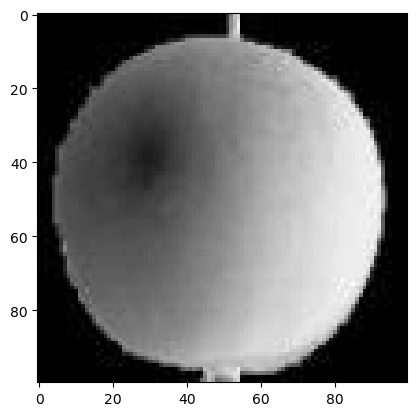

In [102]:
# 이미지로 확인
import matplotlib.pyplot as plt

plt.imshow(
    val_scaled[0].reshape(100, 100),
    cmap='gray'
)
plt.show()

In [103]:
pred = model.predict(
    val_scaled[:1]
)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([[9.9838758e-01, 1.6124785e-03, 4.2761872e-08]], dtype=float32)

In [106]:
# 글자로 변경하기
import numpy as np
classes = ['사과', '파인애플', '바나나']
len(classes)    # 가짓수 확인

3

In [107]:
classes[np.argmax(pred)]        # softmax 를 쓰면 argmax 를 써야 함.

'사과'